In [18]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pypsa.plot.maps.static import add_legend_circles, add_legend_patches

# System-Level Results - CI Procurement Allocation
This notebook includes scripts to evaluate:
1) System-level and CI procurement results
2) CI procurement allocation

## 1 - System-level and CI procurement results
- CI load
- Total system cost
- System CO2 emissions
- Gross generation by source and by country
- CI procurement by source (wind and solar)

In [ ]:
# 0 - functions
solar_carrier = ["solar","solar-hsat","solar rooftop"]
wind_carrier = ["onwind","offwind-ac","offwind-dc","offwind-float"]
carrier_list = solar_carrier + wind_carrier

def get_res_cap(network, only_ci = True):
    n = network.copy()
        
    # Copy time-dependent data
    if only_ci:
        gen = n.generators[n.generators.ci != ""].copy() if "ci" in n.generators.columns else n.generators.loc[[],:]
        link = n.links[n.links.ci != ""].copy() if "ci" in n.links.columns else n.links.loc[[],:]
    else:
        gen = n.generators.copy()
        link = n.links.copy()
    
    solar_cap = round(gen[gen.carrier.isin(solar_carrier)].p_nom_opt.sum() / 1e3) # MW to GW
    wind_cap = round(gen[gen.carrier.isin(wind_carrier)].p_nom_opt.sum() / 1e3) # MW to GW
    
    return [solar_cap, wind_cap]

def get_res_gen(network, only_ci = True):
    n = network.copy()
    weights = n.snapshot_weightings["generators"]
    
    gen = n.generators_t.p.copy()
    link = n.links_t.p1.copy()
        
    # Copy time-dependent data
    if only_ci:
        gen_i = n.generators[n.generators.ci != ""].index if "ci" in n.generators else []
        gen = gen[gen_i]

        link_i = n.links[n.links.ci != ""].index if "ci" in n.links else []
        link = link[link_i]
    
    df_gen = pd.DataFrame(weights @ gen / 1e6) # MWh to TWh
    df_gen["carrier"] = df_gen.index.map(n.generators.carrier)

    df_link = pd.DataFrame(weights @ link / 1e6) # MWh to TWh
    df_link["carrier"] = df_link.index.map(n.links.carrier)

    solar_gen = round(df_gen[df_gen.carrier.isin(solar_carrier)].generators.sum())
    wind_gen = round(df_gen[df_gen.carrier.isin(wind_carrier)].generators.sum())

    return [solar_gen, wind_gen]

def get_solar_wind_curtailment(network):
    n = network.copy()
    df_curt = n.statistics.curtailment(nice_names=False)
    df_gen = n.statistics.energy_balance(nice_names=False)

    df_curt = df_curt[df_curt.index.get_level_values("component") == "Generator"].groupby("carrier").sum()
    df_gen = df_gen[df_gen.index.get_level_values("component") == "Generator"].groupby("carrier").sum()

    solar_curt = df_curt.T[df_curt.index.isin(solar_carrier)].sum()
    wind_curt = df_curt.T[df_curt.index.isin(wind_carrier)].sum()

    solar_gen = df_gen.T[df_gen.index.isin(solar_carrier)].sum()
    wind_gen = df_gen.T[df_gen.index.isin(wind_carrier)].sum()

    solar_c = round((solar_curt/(solar_curt + solar_gen)) * 100)
    wind_c = round((wind_curt/(wind_curt + wind_gen)) * 100)

    return [solar_c, wind_c]

def compile_CI_statistics(network):
    n = network.copy()

    df = pd.DataFrame({"Capacity CI (GW)":get_res_cap(network, only_ci = True),
                       "Capacity (GW)":get_res_cap(network, only_ci = False),
                       "Generation CI (TWh)":get_res_gen(network, only_ci = True),
                       "Generation (TWh)":get_res_gen(network, only_ci = False),
                       "Curtailment (%)":get_solar_wind_curtailment(network)
                      }, index= ["Solar","Wind"])
    
    display(df)
    
def get_gen_by_country_carrier(n, carrier_list):
    df = pd.DataFrame(n.statistics.energy_balance(nice_names = False, comps = ["Generator"], groupby=["country","carrier"])).reset_index().drop(columns="component")
    df_filtered = df[(df.country!="") & (df.carrier.isin(carrier_list))].groupby(["country","carrier"]).sum().unstack(level=1)/10**6 # MWh to TWh
    display(round(df_filtered.fillna(0),2))

def get_cap_by_country_carrier(n, carrier_list):
    df = pd.DataFrame(n.statistics.optimal_capacity(nice_names = False, comps = ["Generator"], groupby=["country","carrier"])).reset_index().drop(columns="component")
    df_filtered = df[(df.country!="") & (df.carrier.isin(carrier_list))].groupby(["country","carrier"]).sum().unstack(level=1)/10**3 # MW to GW
    display(round(df_filtered.fillna(0),2))

In [23]:
# 1 - Retrieve results
planning_horizon = "2030"
time_resolution = "3"
ci_participation = "25"

scenarios = [f"baseline-{planning_horizon}-{time_resolution}H",
             f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
             f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H",
             f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
             f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-{time_resolution}H",
             ]

for scenario in scenarios:
    network = pypsa.Network(f"networks/{scenario}.nc")
    print(f"--------Scenario: {scenario}--------")

    # Get system-level results: CI load
    ci_load_index = network.loads[~network.loads.ci.isin([np.nan,"","None"])].index
    weights = network.snapshot_weightings["generators"]
    load_ci = round((weights @ network.loads_t.p[ci_load_index]).sum()/1e6) # MWh to TWh
    print(f"CI load (TWh): {load_ci}")

    # Get system-level results: total system cost
    system_cost = round(network.objective / 1e9,1)
    if "baseline" in scenario:
        base_cost = system_cost
        print(f"Total system cost (bEUR): {base_cost}")
    else:
        cost_diff = (system_cost - base_cost)/load_ci
        print(f"Total system cost (bEUR): {system_cost}\nDifference compared to base (bEUR/MWh): {round(cost_diff,2)}")

    # Get system-level results: CO2 emissions
    eb = network.statistics.energy_balance(groupby=['country','carrier','bus_carrier','name']).reset_index()
    em = eb[ (eb['bus_carrier']=='co2')].drop(columns=["component", "country","name","bus_carrier"]).groupby(['carrier']).sum()/1e6 # tCO2 to MtCO2
    system_emissions = round(float(-em.loc["co2", 0]), 2)
    if "baseline" in scenario:
        base_emissions = system_emissions
        print(f"System emission (MtCO2): {base_emissions}")
    else:
        em_diff = (system_emissions - base_emissions)/load_ci
        print(f"System emissions (MtCO2): {system_emissions}\nDifference compared to base (MtCO2/MWh): {round(em_diff,2)}")

    # Get CI procurement allocation by source and country
    print("Generation, capacity, and curtailment statistics - solar and wind")
    compile_CI_statistics(network)

    # Get capacity by carrier and country
    print("Capacity by country and carrier(GW)- solar and wind")
    get_cap_by_country_carrier(network, carrier_list)

INFO:pypsa.io:Imported network baseline-2030-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


--------Scenario: baseline-2030-3H--------
CI load (TWh): 0
Total system cost (bEUR): 96.9
System emission (MtCO2): 200.69
Generation, capacity, and curtailment statistics - solar and wind


,Capacity CI (GW),Capacity (GW),Generation CI (TWh),Generation (TWh),Curtailment (%)
Solar,0,925,0,953,11
Wind,0,343,0,879,6


Capacity by country and carrier(GW)- solar and wind


0                                                        \
carrier offwind-ac offwind-dc offwind-float onwind   solar solar rooftop   
country                                                                    
AL            0.00       0.00           0.0   0.00    0.16          1.40   
AT            0.00       0.00           0.0   3.93    6.83         16.12   
BA            0.00       0.00           0.0   0.13    0.12          2.61   
BE            2.26       0.00           0.0   5.56    8.55          7.14   
BG            0.00       0.00           0.0   0.69    2.95          5.23   
CH            0.00       0.00           0.0   0.08    5.84          7.03   
CZ            0.00       0.00           0.0   0.34    2.51         10.75   
DE            8.41      15.56           0.0  54.96  107.54        164.69   
DK            2.61       0.00           0.0  19.45    3.52          7.25   
EE            0.00       0.00           0.0   3.20    0.68          0.00   
ES            0.00       0.00           0.0  28.85   30.89         84.74   
FI            0.07       0.00           0.0   6.85    0.88          0.00   
FR            0.01       6.90           0.0  22.16   20.52         24.83   
GB           14.73       0.00           0.0  43.81   15.64         42.84   
GR            0.00       0.00           0.0   4.99    7.03         10.74   
HR            0.00       0.00           0.0   1.14    0.46          2.86   
HU            0.00       0.00           0.0   0.34    5.83          7.24   
IE            0.03       0.00           0.0   5.49    7.10          8.91   
IT            0.00       0.00           0.0  11.94   29.79         76.34   
LT            0.00       0.00           0.0   2.60    4.15          5.29   
LU            0.00       0.00           0.0   0.21    0.60          1.04   
LV            0.00       0.00           0.0   0.14    0.35          2.69   
ME            0.00       0.00           0.0   0.12    0.04          1.25   
MK            0.00       0.00           0.0   0.11    0.53          1.31   
NL            3.98       0.00           0.0  21.02   23.90          0.00   
NO            0.00       0.00           0.0   5.05    0.60          9.90   
PL            0.00       4.58           0.0  13.14   15.81         28.96   
PT            0.03       0.00           0.0   5.63    3.87         17.30   
RO            1.54       0.00           0.0   3.33    1.93          7.92   
RS            0.00       0.00           0.0   0.51    0.13          1.21   
SE            0.19       0.00           0.0  15.86    3.48         14.81   
SI            0.00       0.00           0.0   0.00    1.04          3.28   
SK            0.00       0.00           0.0   0.00    0.75          2.06   
XK            0.00       0.00           0.0   0.14    0.00          1.25   

                    
carrier solar-hsat  
country             
AL            0.00  
AT            0.00  
BA            0.00  
BE            0.00  
BG            0.00  
CH            0.00  
CZ            0.00  
DE            0.00  
DK            0.00  
EE            0.00  
ES           17.31  
FI            0.00  
FR            0.00  
GB            0.00  
GR            2.57  
HR            0.00  
HU            0.00  
IE            0.00  
IT            0.90  
LT            0.00  
LU            0.00  
LV            0.00  
ME            0.02  
MK            0.00  
NL            0.00  
NO            2.72  
PL            0.00  
PT            8.64  
RO            0.00  
RS            0.00  
SE            0.00  
SI            0.00  
SK            0.00  
XK            0.00

...

INFO:pypsa.io:Imported network emi-match-2030-ci25-model-cmer-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


--------Scenario: emi-match-2030-ci25-model-cmer-3H--------
CI load (TWh): 476
Total system cost (bEUR): 99.5
Difference compared to base (bEUR/MWh): 0.01
System emissions (MtCO2): 201.25
Difference compared to base (MtCO2/MWh): 0.0
Generation, capacity, and curtailment statistics - solar and wind


,Capacity CI (GW),Capacity (GW),Generation CI (TWh),Generation (TWh),Curtailment (%)
Solar,144,926,179,951,11
Wind,80,342,297,882,6


Capacity by country and carrier(GW)- solar and wind


0                                                        \
carrier offwind-ac offwind-dc offwind-float onwind   solar solar rooftop   
country                                                                    
AL            0.00       0.00           0.0   0.00    0.16          1.40   
AT            0.00       0.00           0.0   3.93    6.83         16.12   
BA            0.00       0.00           0.0   0.13    0.12          2.61   
BE            2.26       0.00           0.0   5.29    8.55          7.41   
BG            0.00       0.00           0.0   0.69    2.95          5.23   
CH            0.00       0.00           0.0   0.08    5.84          7.03   
CZ            0.00       0.00           0.0   0.34    2.51         10.75   
DE            8.41      14.79           0.0  54.96  108.31        164.69   
DK            2.61       0.00           0.0  19.37    3.52          7.33   
EE            0.00       0.00           0.0   3.20    0.68          0.00   
ES            0.00       0.00           0.0  28.85   30.86         84.74   
FI            0.07       0.00           0.0   6.85    0.88          0.00   
FR            0.01       6.90           0.0  22.16   20.52         24.83   
GB           14.73       0.00           0.0  46.13   15.64         40.52   
GR            0.00       0.00           0.0   4.99    7.03          7.68   
HR            0.00       0.00           0.0   1.14    0.46          2.86   
HU            0.00       0.00           0.0   0.34    5.83          7.24   
IE            0.03       0.00           0.0   5.54    7.05          8.91   
IT            0.00       0.00           0.0  11.94   29.79         76.09   
LT            0.00       0.00           0.0   2.51    4.25          5.29   
LU            0.00       0.00           0.0   0.21    0.60          1.04   
LV            0.00       0.00           0.0   0.14    0.35          2.69   
ME            0.00       0.00           0.0   0.12    0.04          1.25   
MK            0.00       0.00           0.0   0.11    0.53          1.31   
NL            3.98       0.00           0.0  21.02   23.90          0.00   
NO            0.00       0.00           0.0   5.05    0.60          9.90   
PL            0.00       5.81           0.0  10.97   15.81         29.89   
PT            0.03       0.00           0.0   5.63    3.87         17.30   
RO            0.91       0.00           0.0   3.33    1.93          8.55   
RS            0.00       0.00           0.0   0.51    0.13          1.21   
SE            0.19       0.00           0.0  15.86    3.48         14.81   
SI            0.00       0.00           0.0   0.00    1.04          3.28   
SK            0.00       0.00           0.0   0.00    0.75          2.06   
XK            0.00       0.00           0.0   0.14    0.00          1.25   

                    
carrier solar-hsat  
country             
AL            0.00  
AT            0.00  
BA            0.00  
BE            0.00  
BG            0.00  
CH            0.00  
CZ            0.00  
DE            0.00  
DK            0.00  
EE            0.00  
ES           17.34  
FI            0.00  
FR            0.00  
GB            0.00  
GR            5.63  
HR            0.00  
HU            0.00  
IE            0.00  
IT            1.16  
LT            0.00  
LU            0.00  
LV            0.00  
ME            0.02  
MK            0.00  
NL            0.00  
NO            2.72  
PL            0.00  
PT            8.64  
RO            0.00  
RS            0.00  
SE            0.00  
SI            0.00  
SK            0.00  
XK            0.00

## 2 - CI procurement
This section includes scripts to evaluate CI procurement allocation by sources and country to differen extent:
- `plot_ci_allocation(n)`: to evaluate the carrier share in CI procurement
- `plot_ci_sources(n)`: to evaluate the country share in CI procurement

In [21]:
# 0 - functions
CI_countries = ["Albania",
              "Austria",
              "Bosnia and Herzegovina",
              "Belgium",
              "Bulgaria",
              "Switzerland",
              "Czech Republic",
              "Germany",
              "Denmark",
              "Estonia",
              "Spain",
              "Finland",
              "France",
              "United Kingdom",
              "Greece",
              "Croatia",
              "Hungary",
              "Ireland",
              "Italy",
              "Latvia",
              "Luxembourg",
              "Lithuania",
              "Montenegro",
              "North Macedonia",
              "Netherlands",
              "Norway",
              "Poland",
              "Portugal",
              "Romania",
              "Serbia",
              "Sweden",
              "Slovenia",
              "Slovakia",
              "Kosovo"
              ]

def get_ci_carrier_generation(network, only_ci = True, scenario=None):
    n = network.copy()
    
    # Copy time-dependent data
    gen = n.generators_t.p.copy()
    link = n.links_t.p1.copy()
    sto = n.storage_units_t.p_dispatch.copy()

    if only_ci:
        # Identify components without CI
        gen_i = n.generators[n.generators.ci == ""].index if "ci" in n.generators.columns else []
        link_i = n.links[n.links.ci == ""].index if "ci" in n.links.columns else []
        sto_i = n.storage_units[n.storage_units.ci == ""].index if "ci" in n.storage_units.columns else []
        
        # Zero out non-CI components
        gen[gen_i] = 0
        link[link_i] = 0
        sto[sto_i] = 0
    
    # Create MultiIndex for grouping: (bus, carrier)
    gen.columns = pd.MultiIndex.from_arrays([
        n.generators.bus.reindex(gen.columns),
        n.generators.carrier.reindex(gen.columns),
        n.generators.ci.reindex(gen.columns)
    ])
    if "ci" not in n.links.columns:
        n.links["ci"] = ""
    
    link.columns = pd.MultiIndex.from_arrays([
        n.links.bus1.reindex(link.columns),
        n.links.carrier.reindex(link.columns),
        n.links.ci.reindex(link.columns)
    ])
    sto.columns = pd.MultiIndex.from_arrays([
        n.storage_units.bus.reindex(sto.columns),
        n.storage_units.carrier.reindex(sto.columns),
        n.storage_units.ci.reindex(sto.columns)
    ])
    
    # Group by (bus, carrier)
    gen_grouped = gen.T.groupby(level=[0, 1, 2]).sum().T
    link_grouped = link.T.groupby(level=[0, 1, 2]).sum().T

    # Include import from grid in the link_grouped df
    if "247" in scenario:

        # Change sign to series
        link_grouped.loc[:, link_grouped.columns.get_level_values(0).isin(CI_countries)] *= -1
        # Select and process df portion including imports from grid to CI load nodes
        mask = link_grouped.columns.get_level_values(0).isin(CI_countries)
        cols = link_grouped.columns.to_frame()
        cols.loc[mask & (cols.iloc[:, 1] == "AC"), cols.columns[1]] = "Import from grid"
        cols.loc[mask, cols.columns[2]] = cols.loc[mask, cols.columns[0]]
        link_grouped.columns = pd.MultiIndex.from_frame(cols)
    
    sto_grouped = sto.T.groupby(level=[0, 1, 2]).sum().T 
    
    # Combine and sum across all (bus, carrier) pairs
    all_grouped = pd.concat([gen_grouped, link_grouped], axis=1)
    all_grouped = all_grouped.T.groupby(level=[0, 1, 2]).sum().T
    all_grouped.columns.name = ('bus', 'carrier', 'ci')
    
    # Determine missing buses
    existing_buses = all_grouped.columns.get_level_values(0).unique()
    missing_buses = list(set(n.buses.index) - set(existing_buses))
    
    # Create a MultiIndex with (bus, None, None)
    new_cols = pd.MultiIndex.from_tuples(
        [(bus, None, None) for bus in missing_buses],
        names=all_grouped.columns.names
    )
    
    # Create missing DataFrame filled with 0s
    missing_df = pd.DataFrame(0, index=all_grouped.index, columns=new_cols)
    
    # Concatenate and optionally sort
    df = pd.concat([all_grouped, missing_df], axis=1).sort_index(axis=1)
    df = df.T.groupby(level=[0, 1, 2]).sum().T

    # Fill missing values and convert to GWh
    df = df.fillna(0).div(1e3)

    # readjust the bus location
    old_index = df.columns
    location = [n.buses.loc[val,"location"] for val in df.columns.get_level_values(0)]
    new_columns = pd.MultiIndex.from_arrays([old_index.get_level_values(0),
                                             old_index.get_level_values(1),
                                             old_index.get_level_values(2),
                                             location],
                                            names=["old_bus", "carrier", "ci", "bus"])
    
    df.columns = new_columns
    df = df.T.groupby(level=["bus","carrier","ci"]).sum().T

    all_bus = [val for val in n.buses.index if val not in df.columns.get_level_values(0)]
    new_cols = pd.MultiIndex.from_tuples([(bus, "", "") for bus in all_bus], names=["bus", "carrier", "ci"])
    zero_df = pd.DataFrame(0, index=df.index, columns=new_cols)
    df = pd.concat([df, zero_df], axis=1)

    df = df.T.groupby(level=["bus","carrier","ci"]).sum().T

    df = df.loc[:, df.columns.get_level_values(0) != ""]
    
    return df

def load_projection(plotting_params):
    proj_kwargs = plotting_params.get("projection", dict(name="EqualEarth"))
    proj_func = getattr(ccrs, proj_kwargs.pop("name"))
    return proj_func(**proj_kwargs)

def calculate_global_score(n, name, weights):
    name_p = n.buses_t[f"{name}_p"]
    name_all_p = n.buses_t[f"{name}_all_p"]
    
    numerator = (weights @ name_p).sum()
    denominator = (weights @ name_all_p).sum()
    
    return round(numerator / denominator * 100)

def add_legends(n, df, ax, bus_size_factor, colors):

    # Weights and energy calculations
    weights = n.snapshot_weightings["generators"]
    
    legend_circles = [10, 5, 3, 1]
    legend_x, legend_y = 1.0, 0.5

    # --- Legend schemes ---
    
    global_cfe_score = calculate_global_score(n, "cfe_w_ci", weights)
    global_res_score = calculate_global_score(n, "res_w_ci", weights)
    global_res_score_no_ci = calculate_global_score(n, "res", weights)
    ci_contribution = global_res_score - global_res_score_no_ci
    description = f"Global Score\nCFE Score: {global_cfe_score}%\nRES Score: {global_res_score}%\nCI Contrib.: {ci_contribution}%"
    
    ax.text(
        legend_x + 0.18, legend_y, description, transform=ax.transAxes, verticalalignment='center',horizontalalignment="center",
        bbox=dict(facecolor='white', edgecolor='lightgrey', boxstyle='round,pad=1')
    )

        # --- Bus sizes legend ---
    sizes = [s * 1e3 / bus_size_factor for s in legend_circles]
    labels = [f"{s} TWh" for s in legend_circles]
    
    legend_kw = {
        "loc": "upper left",
        "bbox_to_anchor": (legend_x, 1.0),
        "labelspacing": 0.9,
        "handletextpad": 0,
        "frameon": False,
        "title": r"Energy Generation",
    }
    
    add_legend_circles(
        ax,
        sizes,
        labels,
        srid=n.srid,
        patch_kw={"facecolor": "lightgrey"},
        legend_kw=legend_kw,
    )

    # --- Carrier patches legend ---
    carriers = df[df > 0].index
    legend_colors = [colors[c] for c in carriers]
    legend_labels = list(carriers)

    if len(legend_labels) > 3:
        y_space = 0.10
    else:
        y_space = 0.25
    
    legend_kw.update({
        "loc": "upper left",
        "bbox_to_anchor": (legend_x, legend_y - y_space),
        "handletextpad": 0.2,
        "title": r"Energy Type",
        "alignment": "center",
        "ncol": 1
    })
    
    add_legend_patches(
        ax,
        legend_colors,
        legend_labels,
        legend_kw=legend_kw
    )

def plot_ci_allocation(network, name):

    # Network copy and constants
    n = network.copy()
    
    bus_size_factor = 1e4

    # Weights and energy calculations
    weights = n.snapshot_weightings["generators"]
    
    df = get_ci_carrier_generation(n, scenario=name)

    # Remove negative generations (Batteries)
    df.loc[:, df.sum() < 0.1] = 0
    
    bus_size = weights @ df.T.groupby(level=[0, 1]).sum().T / bus_size_factor
    
    # Get carriers from level 1 of the column MultiIndex
    carriers = df.columns.get_level_values(1).unique()
    
    # Map each carrier to its color (with fallback to "#000000")
    colors = pd.Series(
        [n.carriers.color.get(c) or "#000000" for c in carriers],
        index=carriers,
        name="color"
    )

    if "247" in scenario:
        colors.loc["Import from grid"] = "#800080"  #GC
    
    # Projection and plot setup
    proj = load_projection({})
    
    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": proj})

    n.plot.map(ax=ax, bus_sizes = bus_size, bus_colors = colors, line_widths=0, link_widths=0, boundaries = [-11, 30, 34, 71])

     # --- Add Title ---
    ax.set_title(f"{name} CI procurement generation")
    df = weights @ df.T.groupby(level=[1]).sum().T

    add_legends(n, df, ax, bus_size_factor, colors)

    fig.savefig(f"ci_loc_{name}", bbox_inches="tight")

def plot_ci_sources(network, name):

    color_country_names = {
        "Albania": "#440154",
        "Austria": "#482677",
        "Bosnia and Herzegovina": "#43398e",
        "Belgium": "#3953a4",
        "Bulgaria": "#2c728e",
        "Switzerland": "#228b8d",
        "Czech Republic": "#1f9d8a",
        "Germany": "#29af7f",
        "Denmark": "#3fbc73",
        "Estonia": "#5ec962",
        "Spain": "#84d44b",
        "Finland": "#addc30",
        "France": "#d8e219",
        "United Kingdom": "#fde725",
        "Greece": "#f0f921",
        "Croatia": "#f1c25e",
        "Hungary": "#f4a784",
        "Ireland": "#f78f98",
        "Italy": "#f87ea0",
        "Lithuania": "#f87a9a",
        "Luxembourg": "#f57694",
        "Latvia": "#f3758d",
        "Montenegro": "#f37685",
        "North Macedonia": "#f37b7c",
        "Netherlands": "#FF6666",
        "Norway": "#FF3333",
        "Poland": "#eb0000",
        "Portugal": "#d70000",
        "Romania": "#c00000",
        "Serbia": "#a50000",
        "Sweden": "#8a0000",
        "Slovenia": "#6f0000",
        "Slovakia": "#550000",
    }

    # Network copy and constants
    n = network.copy()
    
    bus_size_factor = 1e4

    # Weights and energy calculations
    weights = n.snapshot_weightings["generators"]
    
    df = get_ci_carrier_generation(n)

    # Remove negative generations (Batteries)
    df.loc[:, df.sum() < 0.1] = 0
    
    bus_size = weights @ df.T.groupby(level=[0, 2]).sum().T / bus_size_factor
    
    # Get carriers from level 2 of the column MultiIndex
    ci_name = df.columns.get_level_values(2).unique()
    
    # Map each carrier to its color (with fallback to "#000000")
    colors = pd.Series(
        [color_country_names[c] or "#000000" if c else "#000000" for c in ci_name],
        index=ci_name,
        name="color"
    )
    
    # Projection and plot setup
    proj = load_projection({})
    
    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": proj})
    
    n.plot.map(ax=ax, bus_sizes = bus_size, bus_colors = colors, line_widths=0, link_widths=0, boundaries = [-11, 30, 34, 71])

     # --- Add Title ---
    ax.set_title(f"{name} CI procurement distribution")
    df = weights @ df.T.groupby(level=[2]).sum().T

    add_legends(n, df, ax, bus_size_factor, colors)

    fig.savefig(f"ci_loc_dist_{name}", bbox_inches="tight")



INFO:pypsa.io:Imported network vol-match-2030-ci25-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pypsa/plot/maps/static.py:1678: UserWarning: When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.
  warnings.warn(
INFO:pypsa.io:Imported network vol-match-2030-country-ci25-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pypsa/plot/maps/static.py:1678: UserWarning: When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.
  warnings.warn(
INFO:p

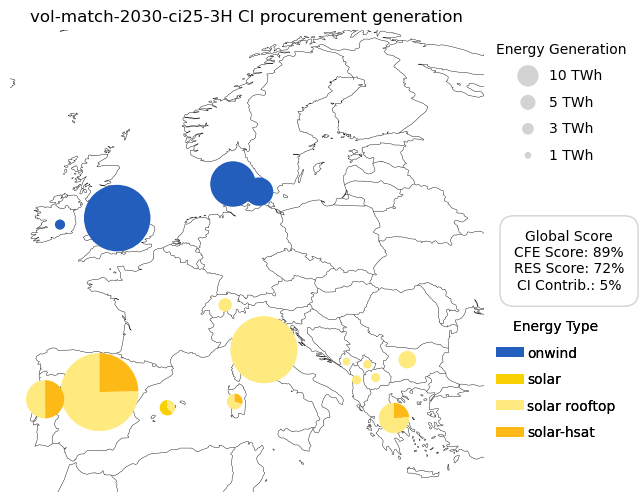

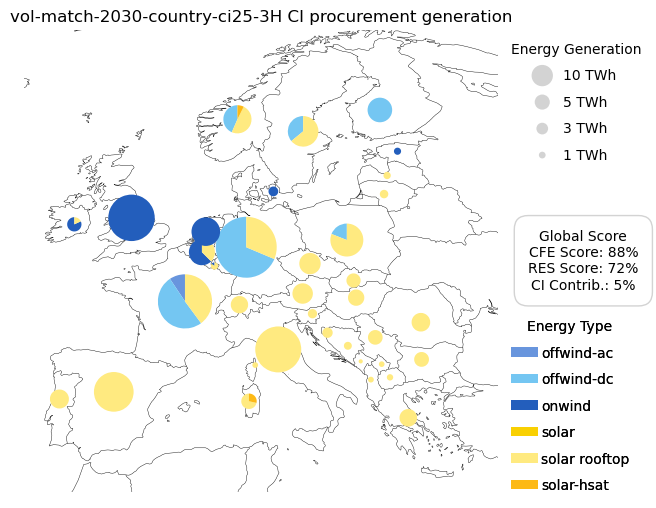

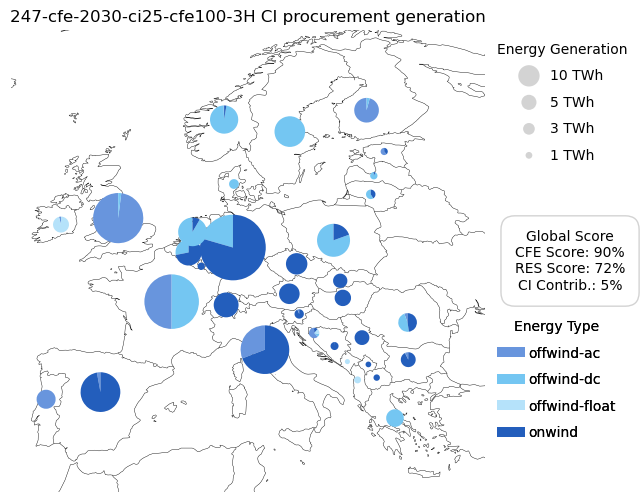

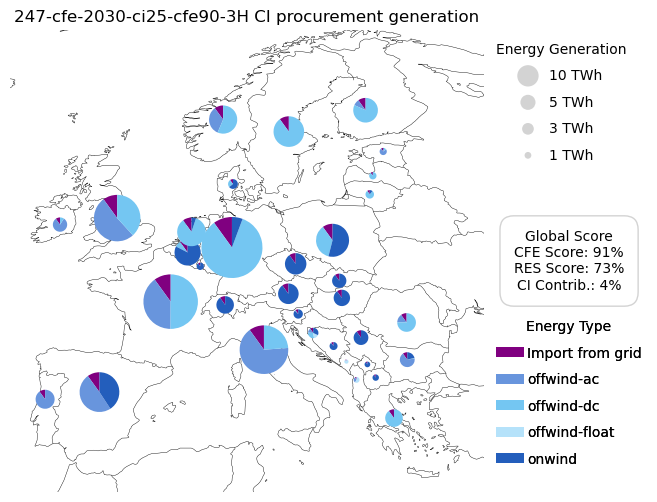

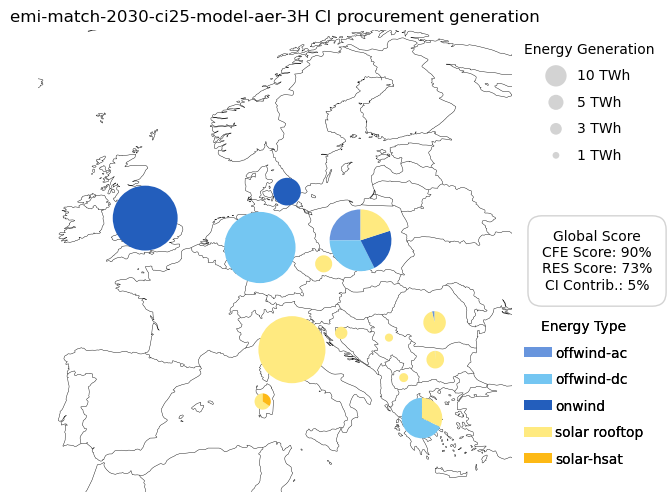

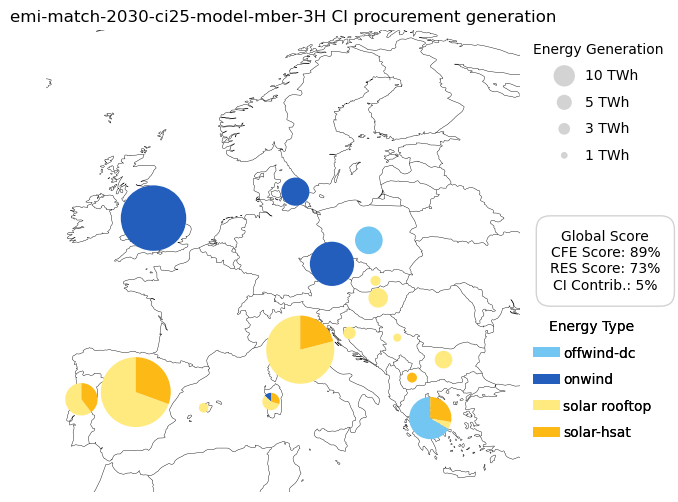

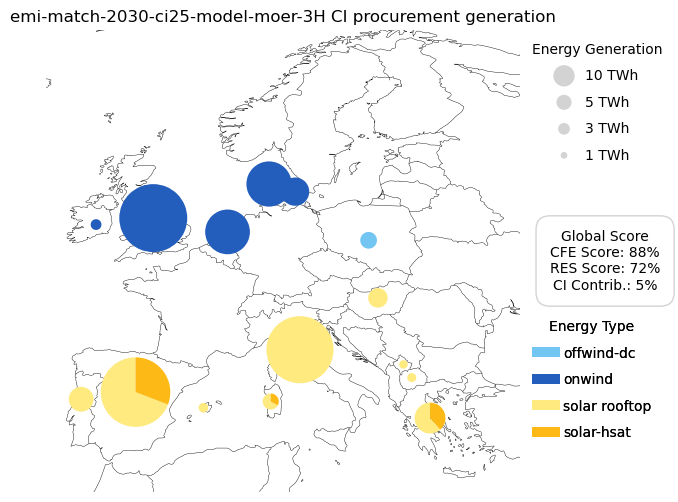

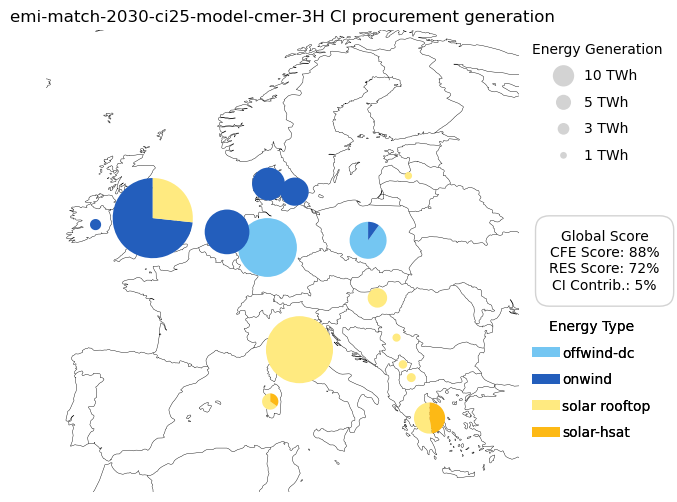

In [22]:
# 1 - Retrieve results
planning_horizon = "2030"
time_resolution = "3"
ci_participation = "25"

scenarios = [f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
             f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H",
             f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
             f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-{time_resolution}H",
             ]

for scenario in scenarios:
    network = pypsa.Network(f"networks/{scenario}.nc")
    plot_ci_allocation(network, scenario)